**USING LSTM FOR MULTICLASS PREDICTION**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install numpy pandas scikit-learn tensorflow matplotlib seaborn shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=ad82fe795de194edba51351a1fa559995cbe925f9e2dd2d796471f8b517f2812
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [4]:
# -*- coding: utf-8 -*-
"""
Context-Aware Quantum-Inspired Intelligence for AI-Aided Cyber Worm Detection
Simulation with QPSO and LSTM for Multiclass Prediction

This Jupyter Notebook integrates a simplified Quantum-Inspired Particle Swarm Optimization
(QPSO) algorithm for feature selection *before* training an LSTM model for
predicting network traffic types from a custom CSV dataset.

The notebook includes:
    1. Loading and preprocessing a custom dataset.
    2. Implementing a simplified QPSO for feature selection.
    3. Preparing sequential data for the LSTM model using selected features.
    4. Building and training the LSTM model for multiclass classification.
    5. Evaluating the model with accuracy, precision, recall, F1-score, and loss.
    6. Plotting accuracy and loss curves during training.
    7. Generating and visualizing the confusion matrix.
    8. Plotting the AUC-ROC curve for each traffic type (One-vs-Rest).

Assumptions about the CSV file:
    - It contains network traffic features and contextual features.
    - One column is the 'traffic_type' column with more than 2 unique traffic types.
    - Data is structured or can be structured as sequential data.
    - Non-numeric columns are converted to numeric.
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Explainability
import shap
import lime
import lime.lime_tabular


# Seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [5]:
# Seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [6]:
# --- 1. Load and Preprocess Custom Dataset ---
csv_file_path = '/content/drive/MyDrive/conquest-milcom/ACI-IoT-2023.csv'  # Replace with the actual path

try:
    df = pd.read_csv(csv_file_path)
    print(f"Dataset loaded successfully from {csv_file_path}")
except FileNotFoundError:
    print(f"Error: CSV file not found at {csv_file_path}")
    exit()

Dataset loaded successfully from /content/drive/MyDrive/conquest-milcom/ACI-IoT-2023.csv


In [7]:
df_dropped = df.drop('Connection Type', axis=1)

In [8]:
print(df_dropped.head())

# To get some basic information about the DataFrame:
print(df_dropped.info())

# To see descriptive statistics:
print(df_dropped.describe())

                                 Flow ID        Src IP  Src Port  \
0  192.168.1.7-54.230.163.60-33344-443-6   192.168.1.7     33344   
1    192.168.3.6-91.189.91.48-36754-80-6   192.168.3.6     36754   
2    192.168.3.6-91.189.91.48-36754-80-6   192.168.3.6     36754   
3   192.168.1.9-192.168.1.1-8080-40426-6   192.168.1.9      8080   
4  192.168.1.20-35.232.111.17-40054-80-6  192.168.1.20     40054   

          Dst IP  Dst Port  Protocol            Timestamp  Flow Duration  \
0  54.230.163.60       443         6  2023-01-11 09:43:40         379933   
1   91.189.91.48        80         6  2023-01-11 09:43:51         205637   
2   91.189.91.48        80         6  2023-01-11 09:43:51              0   
3    192.168.1.1     40426         6  2023-01-11 09:43:49        5030379   
4  35.232.111.17        80         6  2023-01-11 09:43:56          72278   

   Total Fwd Packet  Total Bwd packets  ...  Fwd Seg Size Min  Active Mean  \
0                11                 11  ...             

In [9]:
# Identify the target column
target_column = 'Label'
if target_column not in df_dropped.columns:
    print(f"Error: Target column '{target_column}' not found.")
    exit()

y_original = df_dropped[target_column].values
X = df_dropped.drop(columns=[target_column])

In [10]:
y_original

array(['Benign', 'Benign', 'Benign', ..., 'Benign', 'Benign', 'Benign'],
      dtype=object)

In [11]:
# Count the unique values in the target column
value_counts = df_dropped['Label'].value_counts()
value_counts

,count
Label,
Port Scan,441282
Benign,329295
ICMP Flood,225234
Ping Sweep,71928
DNS Flood,46935
Vulnerability Scan,39537
OS Scan,37524
Slowloris,18643
SYN Flood,13857


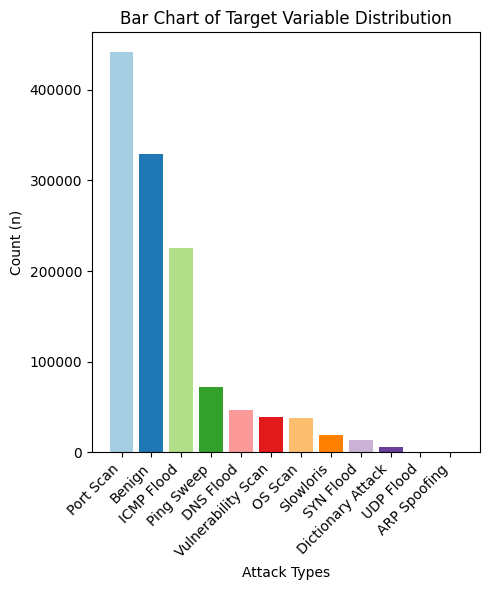

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each unique value in the target column
value_counts = df_dropped['Label'].value_counts()
title ='Bar Chart of Target Variable Distribution'

# Get the unique values (labels) and their counts (heights)
unique_values = value_counts.index
counts = value_counts.values

# Generate a list of distinct colors for each unique value
num_unique = len(unique_values)
colors = sns.color_palette('Paired', n_colors=num_unique) # You can choose other palettes like 'Set2', 'Paired', etc.

# Create the bar chart using seaborn
plt.figure(figsize=(5, 6))  # Adjust figure size as needed
#sns.barplot(x=value_counts.index, y=value_counts.values)
plt.bar(unique_values, counts, color=colors)

# Add labels and title
plt.xlabel('Attack Types')
plt.ylabel('Count (n)')
plt.title(title)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping

# Display the plot
plt.show()

In [13]:
# Convert all non-numeric columns to numeric
for column in X.columns:
    if pd.api.types.is_object_dtype(X[column]):
        try:
            X[column] = pd.to_numeric(X[column], errors='raise')
        except ValueError:
            print(f"Converting non-numeric column: {column}")
            le = LabelEncoder()
            X[column] = le.fit_transform(X[column])
    elif not pd.api.types.is_numeric_dtype(X[column]):
        print(f"Warning: Column '{column}' is not numeric and not string. Handling needed.")

X = X.values  # Convert features to numpy array

Converting non-numeric column: Flow ID
Converting non-numeric column: Src IP
Converting non-numeric column: Dst IP
Converting non-numeric column: Timestamp


In [14]:
X

array([[7.39829000e+05, 6.59380000e+04, 3.33440000e+04, ...,
        0.00000000e+00, 1.69884622e+15, 1.69884622e+15],
       [7.62036000e+05, 6.59510000e+04, 3.67540000e+04, ...,
        0.00000000e+00, 1.69884623e+15, 1.69884623e+15],
       [7.62036000e+05, 6.59510000e+04, 3.67540000e+04, ...,
        0.00000000e+00, 1.69884623e+15, 1.69884623e+15],
       ...,
       [8.51519000e+05, 1.45701000e+05, 0.00000000e+00, ...,
        8.49473017e+14, 1.69894605e+15, 6.83174900e+06],
       [2.31437000e+05, 6.59260000e+04, 5.20460000e+04, ...,
        0.00000000e+00, 1.69894606e+15, 1.69894606e+15],
       [7.75788000e+05, 7.77310000e+04, 4.43000000e+02, ...,
        0.00000000e+00, 1.69894609e+15, 1.69894609e+15]])

In [15]:
# --- 2. Prepare Data for LSTM ---
# Assuming your data is already in a sequential format or can be reshaped.
# LSTM expects input in the shape (samples, time steps, features).

# Determine the number of unique classes in the target variable
unique_classes = np.unique(y_original)
num_classes = len(unique_classes)
print(f"Number of unique classes in the target: {num_classes}")
# %%
# Encode the target variable to numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_original)
# %%
# Convert integer labels to one-hot encoded vectors
y_categorical = to_categorical(y_encoded, num_classes=num_classes)

Number of unique classes in the target: 12


In [16]:
# --- 2. Simplified Quantum-Inspired Particle Swarm Optimization (QPSO) ---
def simple_fitness_evaluation(feature_indices, data, labels):
    """
    Simplified fitness function (variance ratio).  In a real QPSO, this would
    be more complex, considering model performance.
    """
    if not feature_indices:
        return 0
    normal_data = data[labels == 0][:, feature_indices]
    anomalous_data = data[labels == 1][:, feature_indices]
    if normal_data.size == 0 or anomalous_data.size == 0:
        return 0
    return np.var(anomalous_data) / (np.var(normal_data) + 1e-6)
def qpso(data, labels, num_particles=10, iterations=20, num_features_to_select=10):
    """
    Simplified QPSO implementation.  Key differences from true QPSO:
    - Uses a simplified fitness function.
    - Does not have true quantum state representation.
    - Uses a simplified particle update rule.
    """
    n_features = data.shape[1]
    particles = [np.random.choice(n_features, num_features_to_select, replace=False) for _ in range(num_particles)]
    p_best_positions = list(particles)
    p_best_fitnesses = [simple_fitness_evaluation(p, data, labels) for p in particles]
    g_best_position = particles[np.argmax(p_best_fitnesses)]
    g_best_fitness = max(p_best_fitnesses)

    for _ in range(iterations):
        for i in range(num_particles):
            # Simplified particle update (no quantum state)
            phi = np.random.rand()
            p = particles[i]
            x_mean = np.mean(np.array([p_best_positions[i], g_best_position]), axis=0).astype(int)
            new_position = np.zeros_like(p)
            for j in range(len(p)):
                if np.random.rand() < phi:
                    new_position[j] = x_mean[j]
                else:
                    new_position[j] = p[j]

            # Ensure no duplicate features in a particle
            new_position = np.unique(new_position)
            if len(new_position) != num_features_to_select:
                # if the new position has less than num_features_to_select, pad it with random features.
                remaining_features = set(range(n_features)) - set(new_position)
                new_position = np.concatenate((new_position, np.random.choice(list(remaining_features), num_features_to_select - len(new_position), replace=False)))
            particles[i] = new_position

            # Evaluate fitness
            current_fitness = simple_fitness_evaluation(particles[i], data, labels)

            # Update p_best
            if current_fitness > p_best_fitnesses[i]:
                p_best_fitnesses[i] = current_fitness
                p_best_positions[i] = particles[i]

            # Update g_best
            if current_fitness > g_best_fitness:
                g_best_fitness = current_fitness
                g_best_position = particles[i]

    return g_best_position  # Return the indices of the selected features

In [17]:

def simple_fitness_evaluation(feature_indices, data, labels):
    """
    Simplified fitness function (variance ratio).  In a real QPSO, this would
    be more complex, considering model performance.
    """
    # Check if feature_indices is empty using its length
    if len(feature_indices) == 0:
        return 0
    normal_data = data[labels == 0][:, feature_indices]
    anomalous_data = data[labels == 1][:, feature_indices]
    if normal_data.size == 0 or anomalous_data.size == 0:
        return 0
    return np.var(anomalous_data) / (np.var(normal_data) + 1e-6)

In [18]:
# --- 3. Feature Selection with QPSO ---
# Assuming 'labels' is defined (0: normal, 1: anomalous) -  Corrected.
# In a real scenario, you'd adapt the fitness function and QPSO parameters.
#  The 'labels' for QPSO should distinguish between normal and anomalous, not traffic types.
anomaly_labels = (y_original != 'Benign').astype(int) # Example:  Assume 'anything not Benign' is the anomaly


num_features_to_select = 15  # Tune this parameter
selected_feature_indices = qpso(X, anomaly_labels, num_features_to_select=num_features_to_select)
print(f"Selected feature indices: {selected_feature_indices}")

# Reduce the feature set
X_selected = X[:, selected_feature_indices]

/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Selected feature indices: [10 14 23 26 29 32 37 38 43 46 51 56 57 63 79]


In [19]:
# --- 4. Prepare Data for LSTM using Selected Features---
# Reshape input data for LSTM
# The X_selected variable is now defined in the cell above
n_samples = X_selected.shape[0]
n_features = X_selected.shape[1]  # Use the number of *selected* features
n_time_steps = 10  # Example: Sequences of 10 time steps

def create_sequences(data, labels, time_steps):
    Xs, ys = [], []
    for i in range(len(data) - time_steps):
        Xs.append(data[i:(i + time_steps)])
        ys.append(labels[i + time_steps - 1])  # Original line
    return np.array(Xs), np.array(ys)

X_sequences, y_sequences = create_sequences(X_selected, y_categorical, n_time_steps)

# Split data
# Adjust the slicing of y_original to match the length of X_sequences and y_sequences
X_train, X_test, y_train, y_test, y_train_original, y_test_original = train_test_split(
    X_sequences, y_sequences, y_original[n_time_steps:], test_size=0.2, random_state=42, stratify=y_original[n_time_steps:]  # Change here
)
# Scale the data AFTER feature selection
scaler = StandardScaler()

#*** Replace infinite or very large values with NaN ***
X_train = np.nan_to_num(X_train)

#*** Impute NaN values (if any) with the mean of each feature ***
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean') # You can use other strategies like 'median'
X_train_imputed = imputer.fit_transform(X_train.reshape(-1, n_features)) #Fit and transform, but keep it flattened

# Now apply the StandardScaler, remember to reshape *after* scaling:
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_train_scaled = X_train_scaled.reshape(-1, n_time_steps, n_features) #Reshape to 3D for LSTM


# Apply the same preprocessing (NaN handling and imputation) to X_test before scaling
X_test = np.nan_to_num(X_test)
X_test_imputed = imputer.transform(X_test.reshape(-1, n_features)) # Use the same imputer fitted on training data # keep it flattened for scaling
X_test_scaled = scaler.transform(X_test_imputed)
X_test_scaled = X_test_scaled.reshape(-1, n_time_steps, n_features) #Reshape to 3D for LSTM

In [20]:
# --- 5. Build and Train the LSTM Model ---
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(n_time_steps, n_features)))  # Use selected feature count
model.add(Dense(num_classes, activation='softmax'))

# Use SGD optimizer
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)  # You can tune the learning rate
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

epochs = 50
batch_size = 32

history = model.fit(X_train_scaled, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,260 (83.05 KB)

 Trainable params: 21,260 (83.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 254s 9ms/step - accuracy: 0.8246 - loss: 0.6255 - val_accuracy: 0.8524 - val_loss: 0.4722
Epoch 2/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 256s 9ms/step - accuracy: 0.8518 - loss: 0.4684 - val_accuracy: 0.8585 - val_loss: 0.4476
Epoch 3/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 281s 10ms/step - accuracy: 0.8575 - loss: 0.4488 - val_accuracy: 0.8608 - val_loss: 0.4373
Epoch 4/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 302s 9ms/step - accuracy: 0.8603 - loss: 0.4394 - val_accuracy: 0.8626 - val_loss: 0.4309
Epoch 5/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 253s 9ms/step - accuracy: 0.8620 - loss: 0.4337 - val_accuracy: 0.8639 - val_loss: 0.4279
Epoch 6/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 264s 10ms/step - accuracy: 0.8633 - loss: 0.4298 - val_accuracy: 0.8648 - val_loss: 0.4256
Epoch 7/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 248s 9ms/step - accuracy: 0.8644 - loss: 0.4267 - val_accuracy: 0.8662 - val_loss: 0.4228
Epoch 8/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 268s 9ms/step - 

In [21]:
# --- 6. Evaluate the Model and Get Metrics ---
y_pred_prob = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_pred_original = label_encoder.inverse_transform(y_pred_classes)

print("\n--- Evaluation Metrics ---")
accuracy = accuracy_score(y_test_original, y_pred_original)
precision = precision_score(y_test_original, y_pred_original, average='weighted')
recall = recall_score(y_test_original, y_pred_original, average='weighted')
f1 = f1_score(y_test_original, y_pred_original, average='weighted')
loss = model.evaluate(X_test_scaled, y_test, verbose=0)[0]

7697/7697 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step

--- Evaluation Metrics ---


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")
print(f"Loss: {loss:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test_original, y_pred_original))


Accuracy: 0.8514
Precision (weighted): 0.8174
Recall (weighted): 0.8514
F1-Score (weighted): 0.8062
Loss: 0.4065

--- Classification Report ---


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                    precision    recall  f1-score   support

      ARP Spoofing       0.00      0.00      0.00         1
            Benign       0.95      0.93      0.94     65857
         DNS Flood       0.95      0.96      0.96      9387
 Dictionary Attack       0.73      0.75      0.74      1276
        ICMP Flood       0.98      0.99      0.98     45047
           OS Scan       0.48      0.03      0.06      7505
        Ping Sweep       0.38      0.02      0.05     14386
         Port Scan       0.75      0.99      0.85     88257
         SYN Flood       0.72      0.82      0.77      2771
         Slowloris       0.95      0.98      0.96      3729
         UDP Flood       0.17      0.01      0.02       158
Vulnerability Scan       0.52      0.03      0.06      7907

          accuracy                           0.85    246281
         macro avg       0.63      0.54      0.53    246281
      weighted avg       0.82      0.85      0.81    246281



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


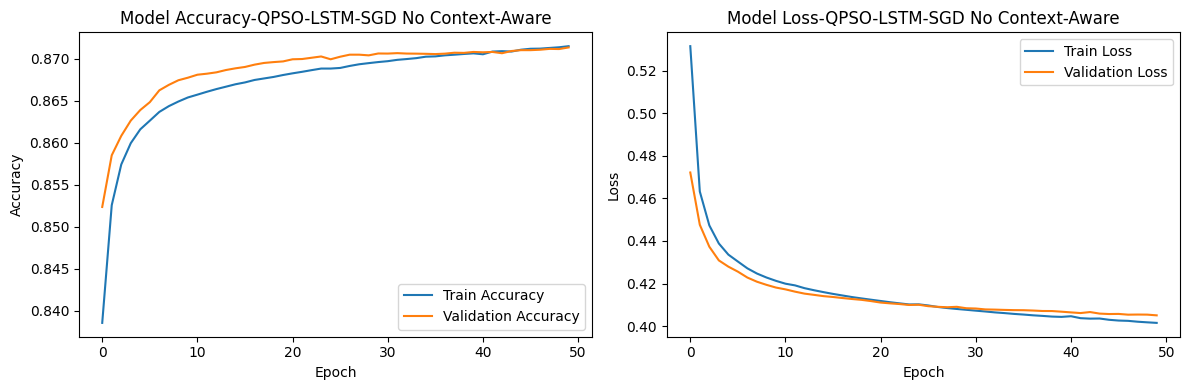

In [26]:
# --- 7. Plotting Training History ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy-QPSO-LSTM-SGD No Context-Aware')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss-QPSO-LSTM-SGD No Context-Aware')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

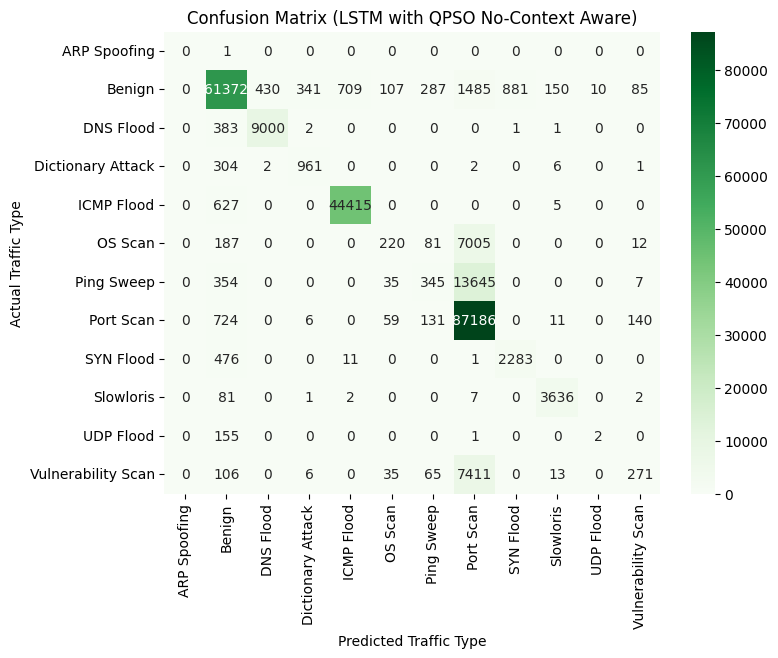

In [25]:
# --- 8. Confusion Matrix ---
conf_matrix = confusion_matrix(y_test_original, y_pred_original)
plt.figure(figsize=(8, 6))

# Get unique traffic types from y_test_original or y_pred_original
unique_traffic_types = np.unique(y_test_original)  # Or use y_pred_original

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=unique_traffic_types, yticklabels=unique_traffic_types)
plt.xlabel('Predicted Traffic Type')
plt.ylabel('Actual Traffic Type')
plt.title('Confusion Matrix (LSTM with QPSO No-Context Aware)')
plt.show()

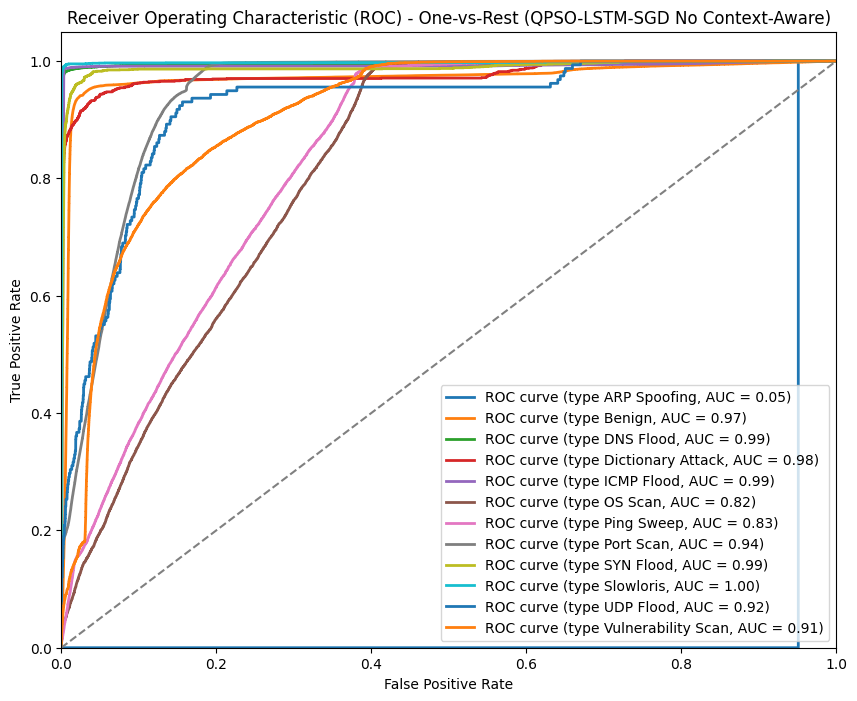


QPSO-LSTM based network traffic type prediction simulation completed.


In [27]:
# --- 9. AUC-ROC Curve (One-vs-Rest) ---
plt.figure(figsize=(10, 8))
lw = 2

y_test_encoded = label_encoder.transform(y_test_original)
y_test_onehot = to_categorical(y_test_encoded, num_classes=num_classes)

for i, traffic_type in enumerate(unique_traffic_types):
    fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=lw, label=f'ROC curve (type {traffic_type}, AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - One-vs-Rest (QPSO-LSTM-SGD No Context-Aware)')
plt.legend(loc="lower right")
plt.show()

print("\nQPSO-LSTM based network traffic type prediction simulation completed.")